# Unit09_Example_01 | 化工案例一：CSTR 反應器動態模擬

本 Notebook 使用 `scipy.integrate.solve_ivp()` 搭配 `method='RK45'` 求解**連續攪拌槽反應器（CSTR）** 的多變數 IVP ODE，探討不同初始條件對系統動態軌跡的影響，並透過相圖分析多重穩態的穩定性。

## 目標
- 建立 CSTR 無因次濃度與溫度動態方程式
- 使用 `solve_ivp(method='RK45')` 求解多變數 IVP（Initial Value Problem）
- 探討不同起始值對系統動態軌跡的影響
- 繪製狀態隨時間變化圖（State Plot）與相圖（Phase Diagram）
- 以相圖分析三個穩態點的穩定性（穩定 vs. 不穩定平衡點）
- 驗證穩態結果與 Unit07 非線性方程式求解結果的一致性

## 目錄
- [0. 環境設定](#0)
- [1. 載入套件](#1)
- [2. 問題描述](#2)
- [3. 單一初始值動態模擬](#3)
- [4. 多初始值相圖分析](#4)
- [5. 穩態驗證](#5)

---
### 0. 環境設定

In [8]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit09_Example_01'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit09'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit09
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_01
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_01\figs


---
### 1. 載入套件

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
import scipy
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題描述

#### 2.1 化工背景

**連續攪拌槽反應器（CSTR，Continuously Stirred Tank Reactor）** 是化工製程中最基本的反應器型式之一。在理想混合假設下，其動態行為由質量平衡與能量平衡耦合決定。

當反應為**放熱反應**且冷卻不足時，CSTR 可能同時存在**三個穩態**，系統的最終狀態取決於初始條件（起始位置）：

| 穩態 | $x_1^*$（無因次濃度）| $x_2^*$（無因次溫升）| 穩定性 |
|------|---------|---------|---------|
| SS1（低溫穩態）| 0.1440 | 0.8860 | 穩定（Stable）|
| SS2（中間穩態）| 0.4472 | 2.7517 | **不穩定（Unstable）**|
| SS3（高溫穩態）| 0.7646 | 4.7050 | 穩定（Stable）|

> 本範例採用 Ray（1981）的無因次 CSTR 模型：
> Ray, W. H. (1981). *Advanced Chemical Reactor Design*. Wiley.

---

#### 2.2 無因次動態方程式

以無因次轉化率 $x_1 \in [0,1)$ 與無因次溫升 $x_2 \geq 0$ 為狀態變數，動態方程式為：

$$
\frac{dx_1}{dt} = -x_1 + Da\,(1-x_1)\,\exp\!\left(\frac{x_2}{1+x_2/\varphi}\right)
$$

$$
\frac{dx_2}{dt} = -(1+\beta)\,x_2 + B\,Da\,(1-x_1)\,\exp\!\left(\frac{x_2}{1+x_2/\varphi}\right) + \beta\,u
$$

其中反應速率項 $r(x_2) = \exp\!\left(\dfrac{x_2}{1+x_2/\varphi}\right)$ 為無因次 Arrhenius 速率。

---

#### 2.3 模型參數

| 參數 | 符號 | 數值 | 物理意義 |
|------|------|------|---------|
| 無因次反應熱 | $B$ | 8.0 | 放熱強度 |
| Damköhler 數 | $Da$ | 0.072 | 反應速率 vs. 流量 |
| 無因次活化能 | $\varphi$ | 20.0 | Arrhenius 溫度敏感性 |
| 無因次冷卻係數 | $\beta$ | 0.3 | 冷卻強度 |
| 外部輸入 | $u$ | 0.0 | 無外部干擾（自治系統）|

In [10]:
# ============================================================
# CSTR 動態模型定義
# ============================================================

# --- 模型參數 ---
Da   = 0.072   # Damköhler 數
phi  = 20.0    # 無因次活化能
B    = 8.0     # 無因次反應熱
beta = 0.3     # 無因次冷卻係數
u    = 0.0     # 外部輸入（自治系統）


def cstr_ode(t, x, Da=Da, phi=phi, B=B, beta=beta, u=u):
    """
    CSTR 無因次動態方程式 (Ray, 1981)

    狀態變數:
        x[0] = x1: 無因次轉化率（濃度）
        x[1] = x2: 無因次溫升（溫度）

    參數:
        Da   : Damköhler 數
        phi  : 無因次活化能
        B    : 無因次反應熱
        beta : 無因次冷卻係數
        u    : 外部輸入

    返回:
        [dx1/dt, dx2/dt]
    """
    x1, x2 = x
    r = np.exp(x2 / (1.0 + x2 / phi))          # 無因次 Arrhenius 速率
    dx1 = -x1 + Da * (1.0 - x1) * r
    dx2 = -(1.0 + beta) * x2 + B * Da * (1.0 - x1) * r + beta * u
    return [dx1, dx2]


# --- 已知三個穩態點（來自 Unit07 非線性方程式求解）---
SS1 = np.array([0.1440, 0.8860])   # 低溫穩態（穩定）
SS2 = np.array([0.4472, 2.7517])   # 中間穩態（不穩定）
SS3 = np.array([0.7646, 4.7050])   # 高溫穩態（穩定）

print("CSTR 模型參數：")
print(f"  Da={Da}, phi={phi}, B={B}, beta={beta}, u={u}")
print(f"\n三個穩態點：")
print(f"  SS1 (穩定)  : x1*={SS1[0]:.4f}, x2*={SS1[1]:.4f}")
print(f"  SS2 (不穩定): x1*={SS2[0]:.4f}, x2*={SS2[1]:.4f}")
print(f"  SS3 (穩定)  : x1*={SS3[0]:.4f}, x2*={SS3[1]:.4f}")

CSTR 模型參數：
  Da=0.072, phi=20.0, B=8.0, beta=0.3, u=0.0

三個穩態點：
  SS1 (穩定)  : x1*=0.1440, x2*=0.8860
  SS2 (不穩定): x1*=0.4472, x2*=2.7517
  SS3 (穩定)  : x1*=0.7646, x2*=4.7050


---
### 3. 單一初始值動態模擬

使用預設初始條件 $x_1(0)=0.1$，$x_2(0)=1.0$（靠近 SS1 低溫穩態），以 `solve_ivp(method='RK45')` 求解 $t \in [0, 20]$，並繪製：

1. **狀態時間圖（State vs. Time Plot）**：觀察 $x_1(t)$ 與 $x_2(t)$ 的暫態響應與收斂情形
2. **相圖（Phase Diagram）**：觀察系統在相平面上的軌跡方向

solver status : 0  (The solver successfully reached the end of the integration interval.)
time steps    : 500
final state   : x1=0.1440, x2=0.8860


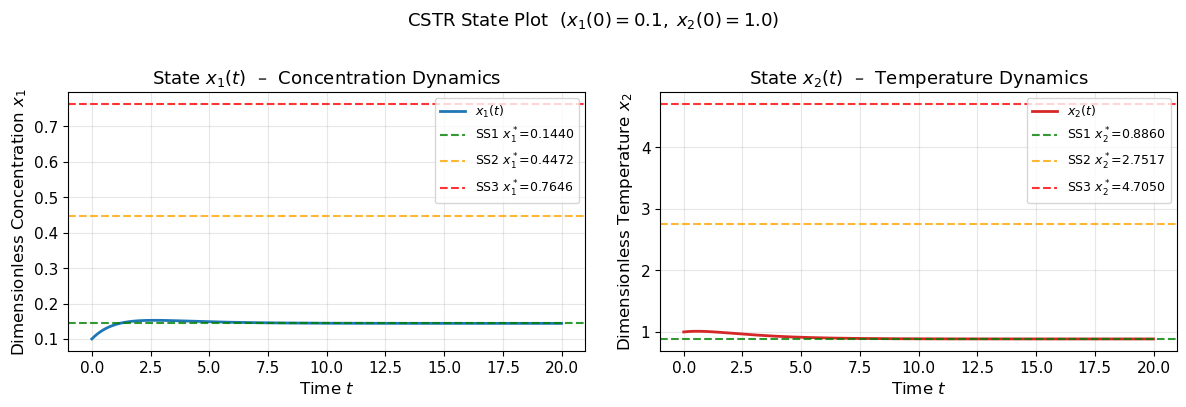

✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_01\figs\fig01_state_plot.png


In [11]:
# ============================================================
# 單一初始值模擬（預設 IC：趨向 SS1）
# ============================================================

# 模擬設定
t_span = (0, 20)
t_eval = np.linspace(0, 20, 500)
x0     = [0.1, 1.0]          # 初始條件 x1(0)=0.1, x2(0)=1.0

# 求解 ODE（RK45）
sol = solve_ivp(
    fun=cstr_ode,
    t_span=t_span,
    y0=x0,
    method='RK45',
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-10
)

print(f"solver status : {sol.status}  ({sol.message})")
print(f"time steps    : {sol.t.shape[0]}")
print(f"final state   : x1={sol.y[0, -1]:.4f}, x2={sol.y[1, -1]:.4f}")

# ============================================================
# 圖 1: 狀態時間圖
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1, ax2 = axes

# --- 左圖：x1(t) ---
ax1.plot(sol.t, sol.y[0], color='tab:blue', label=r'$x_1(t)$')
ax1.axhline(SS1[0], color='green',  ls='--', lw=1.5, alpha=0.8, label=f'SS1 $x_1^*$={SS1[0]:.4f}')
ax1.axhline(SS2[0], color='orange', ls='--', lw=1.5, alpha=0.8, label=f'SS2 $x_1^*$={SS2[0]:.4f}')
ax1.axhline(SS3[0], color='red',    ls='--', lw=1.5, alpha=0.8, label=f'SS3 $x_1^*$={SS3[0]:.4f}')
ax1.set_xlabel('Time $t$')
ax1.set_ylabel('Dimensionless Concentration $x_1$')
ax1.set_title(r'State $x_1(t)$  –  Concentration Dynamics')
ax1.legend(fontsize=9)

# --- 右圖：x2(t) ---
ax2.plot(sol.t, sol.y[1], color='tab:red', label=r'$x_2(t)$')
ax2.axhline(SS1[1], color='green',  ls='--', lw=1.5, alpha=0.8, label=f'SS1 $x_2^*$={SS1[1]:.4f}')
ax2.axhline(SS2[1], color='orange', ls='--', lw=1.5, alpha=0.8, label=f'SS2 $x_2^*$={SS2[1]:.4f}')
ax2.axhline(SS3[1], color='red',    ls='--', lw=1.5, alpha=0.8, label=f'SS3 $x_2^*$={SS3[1]:.4f}')
ax2.set_xlabel('Time $t$')
ax2.set_ylabel('Dimensionless Temperature $x_2$')
ax2.set_title(r'State $x_2(t)$  –  Temperature Dynamics')
ax2.legend(fontsize=9)

fig.suptitle(r'CSTR State Plot  ($x_1(0)=0.1,\; x_2(0)=1.0$)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig01_state_plot.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"✓ 圖檔儲存：{FIG_DIR / 'fig01_state_plot.png'}")

---
### 4. 多初始值相圖分析

選取**多組不同初始條件**，分別求解至 $t=20$，並將所有軌跡繪製於同一相平面（Phase Plane）上。

透過相圖可直觀看出：
- **SS1、SS3**：軌跡向其收斂 → 穩定平衡點（Stable Node / Focus）
- **SS2**：軌跡從其附近發散 → 不穩定平衡點（Saddle Point）
- **分隔線（Separatrix）**：隱性地分隔兩個吸引盆（Basin of Attraction）

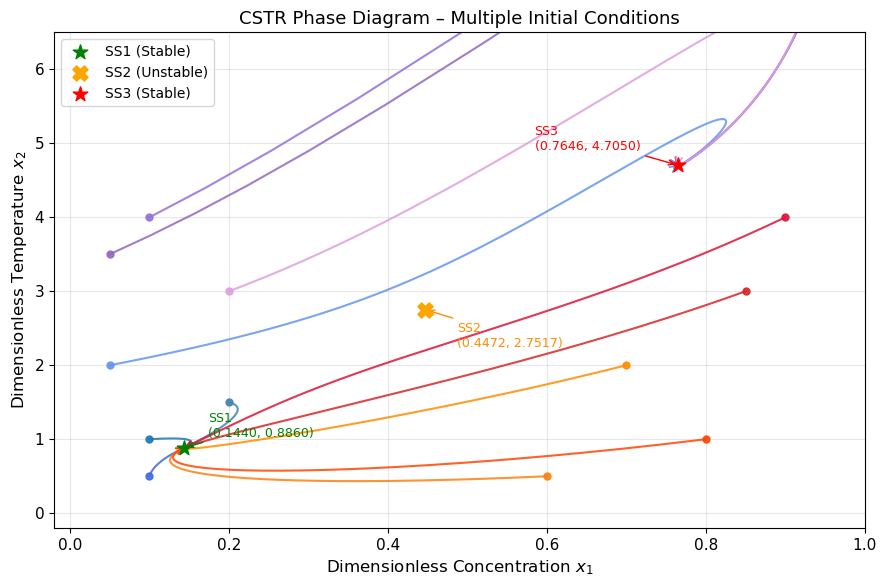

✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_01\figs\fig02_phase_diagram.png


In [12]:
# ============================================================
# 多初始值相圖：State Trajectories in Phase Plane
# ============================================================

# --- 多組初始條件設定 ---
initial_conditions = [
    # (x1_0, x2_0, label_color)
    (0.10, 1.00, 'tab:blue'),      # 靠近 SS1 (穩定)
    (0.10, 0.50, 'royalblue'),
    (0.05, 2.00, 'cornflowerblue'),
    (0.20, 1.50, 'steelblue'),
    (0.05, 3.50, 'tab:purple'),    # 跨越分隔線（趨向 SS3）
    (0.10, 4.00, 'mediumpurple'),
    (0.20, 3.00, 'plum'),
    (0.60, 0.50, 'tab:orange'),    # 趨向 SS3 (穩定)
    (0.70, 2.00, 'darkorange'),
    (0.80, 1.00, 'orangered'),
    (0.85, 3.00, 'tab:red'),
    (0.90, 4.00, 'crimson'),
]

fig, ax = plt.subplots(figsize=(9, 6))

for x1_0, x2_0, color in initial_conditions:
    sol = solve_ivp(
        fun=cstr_ode,
        t_span=(0, 30),
        y0=[x1_0, x2_0],
        method='RK45',
        t_eval=np.linspace(0, 30, 800),
        rtol=1e-8, atol=1e-10
    )
    ax.plot(sol.y[0], sol.y[1], color=color, lw=1.5, alpha=0.85)
    # 起點標記
    ax.plot(x1_0, x2_0, 'o', color=color, ms=5, alpha=0.9)
    # 終點箭頭（方向感）
    mid = len(sol.t) // 2
    ax.annotate('', xy=(sol.y[0, mid+5], sol.y[1, mid+5]),
                xytext=(sol.y[0, mid], sol.y[1, mid]),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

# --- 穩態點標記 ---
ax.scatter(*SS1, s=120, color='green', zorder=5, marker='*', label='SS1 (Stable)')
ax.scatter(*SS2, s=120, color='orange', zorder=5, marker='X', label='SS2 (Unstable)')
ax.scatter(*SS3, s=120, color='red', zorder=5, marker='*', label='SS3 (Stable)')

# --- 穩態座標標籤 ---
ax.annotate(f'SS1\n({SS1[0]:.4f}, {SS1[1]:.4f})',
            xy=SS1, xytext=(SS1[0]+0.03, SS1[1]+0.15),
            fontsize=9, color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=1))
ax.annotate(f'SS2\n({SS2[0]:.4f}, {SS2[1]:.4f})',
            xy=SS2, xytext=(SS2[0]+0.04, SS2[1]-0.5),
            fontsize=9, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1))
ax.annotate(f'SS3\n({SS3[0]:.4f}, {SS3[1]:.4f})',
            xy=SS3, xytext=(SS3[0]-0.18, SS3[1]+0.2),
            fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1))

ax.set_xlabel('Dimensionless Concentration $x_1$')
ax.set_ylabel('Dimensionless Temperature $x_2$')
ax.set_title('CSTR Phase Diagram – Multiple Initial Conditions')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(-0.02, 1.0)
ax.set_ylim(-0.2, 6.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig02_phase_diagram.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"✓ 圖檔儲存：{FIG_DIR / 'fig02_phase_diagram.png'}")

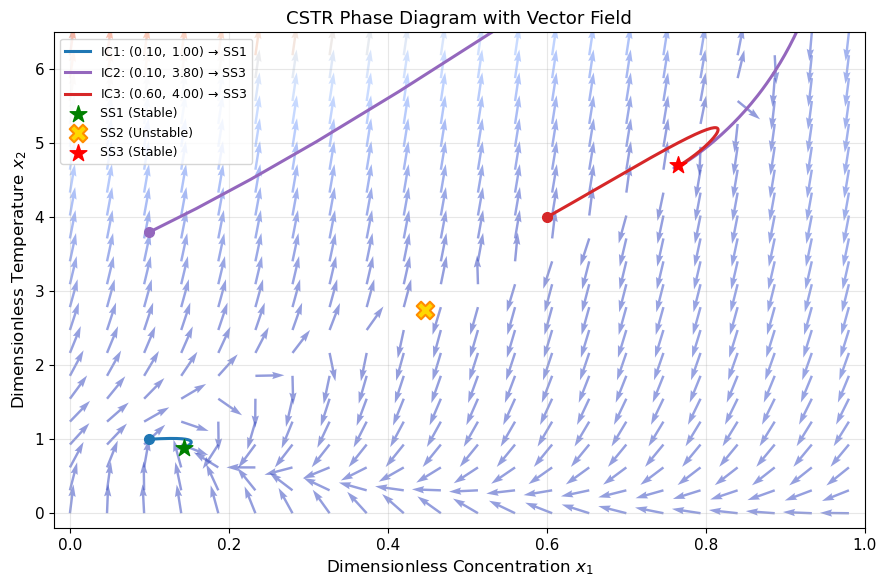

✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_01\figs\fig03_phase_vectorfield.png


In [15]:
# ============================================================
# 向量場（Vector Field）疊加相圖
# 方向箭頭顯示相平面上的流向
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

# --- 向量場網格 ---
x1_g = np.linspace(0.0, 0.98, 22)
x2_g = np.linspace(0.0, 6.5,  22)
X1, X2 = np.meshgrid(x1_g, x2_g)
U = np.zeros_like(X1)
V = np.zeros_like(X2)

for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        dxdt = cstr_ode(0, [X1[i, j], X2[i, j]])
        U[i, j] = dxdt[0]
        V[i, j] = dxdt[1]

# 正規化向量長度（只顯示方向）
N = np.sqrt(U**2 + V**2)
N[N == 0] = 1.0
ax.quiver(X1, X2, U/N, V/N, N,
          cmap='coolwarm', alpha=0.55, scale=28, width=0.003)

# --- 軌跡疊加（3 條代表性軌跡）---
rep_ics = [(0.10, 1.00), (0.10, 3.80), (0.60, 4.00)]
rep_cols = ['tab:blue', 'tab:purple', 'tab:red']
rep_labels = [r'IC1: $(0.10,\;1.00)$ → SS1', r'IC2: $(0.10,\;3.80)$ → SS3',
              r'IC3: $(0.60,\;4.00)$ → SS3']

for (x1_0, x2_0), col, lbl in zip(rep_ics, rep_cols, rep_labels):
    s = solve_ivp(cstr_ode, (0, 30), [x1_0, x2_0], method='RK45',
                  t_eval=np.linspace(0, 30, 800), rtol=1e-8, atol=1e-10)
    ax.plot(s.y[0], s.y[1], color=col, lw=2.2, label=lbl)
    ax.plot(x1_0, x2_0, 'o', color=col, ms=7)

# --- 穩態點 ---
ax.scatter(*SS1, s=160, color='green',  zorder=6, marker='*', label='SS1 (Stable)')
ax.scatter(*SS2, s=160, color='gold',   zorder=6, marker='X', edgecolors='darkorange',
           linewidths=1.5, label='SS2 (Unstable)')
ax.scatter(*SS3, s=160, color='red',    zorder=6, marker='*', label='SS3 (Stable)')

ax.set_xlabel('Dimensionless Concentration $x_1$')
ax.set_ylabel('Dimensionless Temperature $x_2$')
ax.set_title('CSTR Phase Diagram with Vector Field')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(-0.02, 1.0)
ax.set_ylim(-0.2, 6.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig03_phase_vectorfield.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"✓ 圖檔儲存：{FIG_DIR / 'fig03_phase_vectorfield.png'}")

---
### 5. 穩態驗證與動態收斂比較

透過以下兩步驟驗證：

1. **`fsolve` 求解穩態**：令 $dx_1/dt=0, dx_2/dt=0$，數值求解三個穩態點，與 Unit07 結果比對
2. **動態收斂驗證**：從靠近每個穩態點的初始條件出發，觀察 ODE 動態解的收斂行為

穩態數值求解（fsolve）驗證

SS1 (預期穩定)
  初始猜值: x1=0.10, x2=0.80
  求解結果: x1*=0.1440, x2*=0.8860  ✓
  殘差最大值: 2.78e-17
  與 Unit07 結果誤差: 4.6529e-05

SS2 (預期不穩定)
  初始猜值: x1=0.45, x2=2.70
  求解結果: x1*=0.4472, x2*=2.7517  ✓
  殘差最大值: 0.00e+00
  與 Unit07 結果誤差: 6.2524e-05

SS3 (預期穩定)
  初始猜值: x1=0.75, x2=4.70
  求解結果: x1*=0.7646, x2*=4.7050  ✓
  殘差最大值: 1.78e-15
  與 Unit07 結果誤差: 3.9490e-05

動態收斂驗證（從穩態附近 ±0.05 擾動出發）


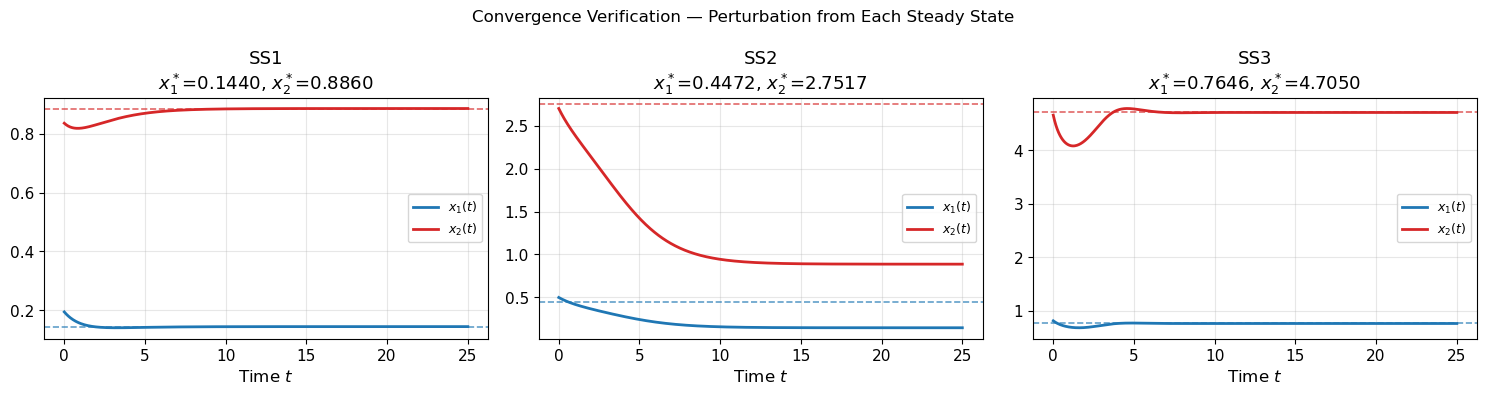


✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_01\figs\fig04_convergence_verify.png


In [16]:
# ============================================================
# 穩態驗證 - fsolve 數值求解 & 動態收斂比對
# ============================================================

def cstr_steady_state(x):
    """穩態方程式：dx/dt = 0"""
    return cstr_ode(0, x)

# --- 1. 用 fsolve 從三組初始猜值求解穩態 ---
print("=" * 52)
print("穩態數值求解（fsolve）驗證")
print("=" * 52)

guesses = [[0.10, 0.80], [0.45, 2.70], [0.75, 4.70]]
ss_labels = ['SS1 (預期穩定)', 'SS2 (預期不穩定)', 'SS3 (預期穩定)']
ss_ref    = [SS1, SS2, SS3]

fsolve_results = []
for g, lbl, ref in zip(guesses, ss_labels, ss_ref):
    xs, info, ier, msg = fsolve(cstr_steady_state, g, full_output=True)
    residual = np.max(np.abs(cstr_steady_state(xs)))
    err = np.linalg.norm(xs - ref)
    fsolve_results.append(xs.copy())
    status = "✓" if ier == 1 else "✗"
    print(f"\n{lbl}")
    print(f"  初始猜值: x1={g[0]:.2f}, x2={g[1]:.2f}")
    print(f"  求解結果: x1*={xs[0]:.4f}, x2*={xs[1]:.4f}  {status}")
    print(f"  殘差最大值: {residual:.2e}")
    print(f"  與 Unit07 結果誤差: {err:.4e}")

# --- 2. 動態收斂驗證（從穩態附近擾動出發）---
print("\n" + "=" * 52)
print("動態收斂驗證（從穩態附近 ±0.05 擾動出發）")
print("=" * 52)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
perturb = [0.05, 0.05]

for ax, (xs, lbl, ref) in zip(axes, zip(fsolve_results, ss_labels, ss_ref)):
    x0_p = [xs[0] + perturb[0], xs[1] - perturb[1]]

    s = solve_ivp(cstr_ode, (0, 25), x0_p, method='RK45',
                  t_eval=np.linspace(0, 25, 600), rtol=1e-8, atol=1e-10)

    ax.plot(s.t, s.y[0], label=r'$x_1(t)$', color='tab:blue')
    ax.plot(s.t, s.y[1], label=r'$x_2(t)$', color='tab:red')
    ax.axhline(xs[0], color='tab:blue',  ls='--', lw=1.2, alpha=0.7)
    ax.axhline(xs[1], color='tab:red',   ls='--', lw=1.2, alpha=0.7)
    ax.set_xlabel('Time $t$')
    ax.set_title(f'{lbl[:3]}\n$x_1^*$={xs[0]:.4f}, $x_2^*$={xs[1]:.4f}')
    ax.legend(fontsize=9)

fig.suptitle('Convergence Verification — Perturbation from Each Steady State', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig04_convergence_verify.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\n✓ 圖檔儲存：{FIG_DIR / 'fig04_convergence_verify.png'}")

---
### 課程總結

#### 學習重點回顧

| 主題 | 說明 |
|------|------|
| **多變數 IVP ODE** | CSTR 系統由兩個耦合 ODE 組成，須以向量形式傳入 `solve_ivp` |
| **RK45 方法** | `method='RK45'` 為顯式 Runge-Kutta 自適應步長，適用於非剛性（non-stiff）問題 |
| **初始條件影響** | 不同 IC 決定系統最終收斂至哪個穩態，展現多重穩態的**歷史依賴性** |
| **相圖（Phase Diagram）** | 在相平面 $(x_1, x_2)$ 上可直觀看出各穩態的吸引盆邊界 |
| **向量場（Vector Field）** | 以 `quiver` 視覺化 $(\dot{x}_1, \dot{x}_2)$ 方向，輔助理解流向 |
| **穩態驗證** | ODE 動態解收斂到與 `fsolve`（Unit07）完全一致的穩態值 |

#### 物理意義

- **SS1（低溫穩態）**：進料條件不足以點火，反應幾乎未進行
- **SS2（中間不穩定態）**：任何微小擾動都會使系統偏離，操作上難以維持
- **SS3（高溫穩態）**：反應充分進行，轉化率高，但溫升也高需注意熱管理

#### 延伸思考

1. 若加入外部輸入 $u \neq 0$（如升溫或冷卻），系統行為如何改變？
2. 如何用 **Jacobian 特徵值分析**定量判斷各穩態的穩定性？
3. **S 形分岔圖**（Bifurcation Diagram）如何描述系統隨 $Da$ 變化的多重穩態轉移？

> 以上問題詳見 Unit07_Example_04（多重穩態分析與分岔圖）。